## 環境設置

In [1]:
try:
    import openseespy.opensees as ops  # noqa: F401
    print("openseespy 已存在,略過安裝")
except ImportError:
    import sys
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops  # noqa: F401

try:
    import numpy as np  # noqa: F401
except ImportError:
    import sys
    !{sys.executable} -m pip install -q numpy

openseespy 已存在,略過安裝


# Case-03.5:試設斷面(Trial Sizing)

依 [ROADMAP.md](../ROADMAP.md) 規劃,這是連接抽象驗證(Case-01~03)跟
真實桃園案例(Case-04)的橋樑。到 Case-03 為止,手上只有地震力**需求**
(F1、F2)跟抽象的斷面性質(Ic、Ib 是隨便設的數字),完全沒有任何
真實 RC 斷面。等值靜力法算出的是需求,不是斷面——這一步要先給一組
合理的試設斷面,才能建真正的模型去檢核。

**流程**:試設斷面 → 建模分析 → 檢核層間位移角(規範 0.005)→
不夠就放大斷面重跑。這個迴圈本身就是結構設計的常態,這裡刻意示範
一次真正的失敗案例,不是只展示一次到位的成功結果。

## 第 1 課:力的來源——誠實交代這裡用的假設

Case-02/03 用的一跨(L=6m)構架,幾何上對應桃園案例 Y 向那一榀構架
(1 跨、2 柱)。但桃園案例算出的 F1=39.75kN、F2=63.60kN 是**整棟樓
8 根柱**的總力,不是這一榀單獨扛的力。

這裡假設 Y 向有 4 榀這種構架平均分攤總力(**這是簡化假設**,真正的
分配比例要等 Case-05 的三維模型才驗證得出來,現階段先用這個假設
讓試設流程能夠往下走)。

In [2]:
F1_total, F2_total = 39.75, 63.60   # kN, 桃園案例整棟樓(8柱)算出的樓層力
n_frames_Y = 4                        # 假設Y向4榀構架平均分攤

F1_frame = F1_total / n_frames_Y
F2_frame = F2_total / n_frames_Y

print(f"整棟樓樓層力: F1={F1_total} kN, F2={F2_total} kN")
print(f"假設{n_frames_Y}榀Y向構架平均分攤,單榀構架力:")
print(f"  F1_frame = {F1_frame:.4f} kN")
print(f"  F2_frame = {F2_frame:.4f} kN")

整棟樓樓層力: F1=39.75 kN, F2=63.6 kN
假設4榀Y向構架平均分攤,單榀構架力:
  F1_frame = 9.9375 kN
  F2_frame = 15.9000 kN


## 第 2 課:混凝土材料性質

用 ACI 經驗公式從抗壓強度 fc' 反推彈性模數 E(這是業界通用的估算式,
不是台灣規範獨有,但台灣規範對此沒有另訂公式時普遍採用這個)。

$$E_c = 4700\sqrt{f_c'} \quad \text{(MPa)}$$

In [3]:
fc_MPa = 27.46   # MPa, 相當於280 kgf/cm^2, 常見RC結構混凝土等級
E_MPa = 4700*(fc_MPa**0.5)
E = E_MPa*1000   # 換算成 kN/m^2, 跟前面幾個Case單位一致

h1 = h2 = 3.5   # m, 沿用桃園案例層高

print(f"fc' = {fc_MPa} MPa")
print(f"E = 4700*sqrt(fc') = {E_MPa:.1f} MPa = {E:.4e} kN/m^2")

fc' = 27.46 MPa
E = 4700*sqrt(fc') = 24629.1 MPa = 2.4629e+07 kN/m^2


## 第 3 課:試設斷面第 0 輪——刻意選一個偏小的斷面

先示範失敗案例,不是因為湊巧選錯,是為了讓「不夠就放大重跑」這個
迴圈有真正的內容可以看,不是只講一次到位的成功故事。

沿用 Case-03 已經驗證過的剪力構架建模方法(ops.fix 拘束轉角與軸向、
ops.equalDOF 綁定樓板)——這個方法在 Case-03 已經證明跟手算精確解
完全吻合,這裡直接套用,不需要重新驗證建模方法本身,只需要驗證新的
斷面數字算出來的結果。

In [4]:
def build_and_analyze(h_col, E, h1, h2, F1_frame, F2_frame, L=6.0):
    """用Case-03驗證過的剪力構架方法, 對給定的方形柱斷面尺寸建模分析,
    回傳 (u1, u2, drift1, drift2, Ic)"""
    Ic = h_col**4/12

    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.node(1, 0.0, 0.0);   ops.node(2, L, 0.0)
    ops.node(3, 0.0, h1);    ops.node(4, L, h1)
    ops.node(5, 0.0, h1+h2); ops.node(6, L, h1+h2)
    ops.fix(1,1,1,1); ops.fix(2,1,1,1)
    for n in [3,4,5,6]:
        ops.fix(n, 0,1,1)
    ops.equalDOF(3,4,1)
    ops.equalDOF(5,6,1)

    A_big = 1.0e6
    ops.geomTransf('Linear', 1)
    ops.element('elasticBeamColumn',1,1,3,A_big,E,Ic,1)
    ops.element('elasticBeamColumn',2,2,4,A_big,E,Ic,1)
    ops.element('elasticBeamColumn',3,3,5,A_big,E,Ic,1)
    ops.element('elasticBeamColumn',4,4,6,A_big,E,Ic,1)

    ops.timeSeries('Linear',1); ops.pattern('Plain',1,1)
    ops.load(3, F1_frame, 0.0, 0.0)
    ops.load(5, F2_frame, 0.0, 0.0)
    ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Transformation')
    ops.test('NormDispIncr',1e-10,20); ops.algorithm('Newton')
    ops.integrator('LoadControl',1.0); ops.analysis('Static'); ops.analyze(1)

    u1 = ops.nodeDisp(3,1)
    u2 = ops.nodeDisp(5,1)
    drift1 = u1/h1
    drift2 = (u2-u1)/h2
    return u1, u2, drift1, drift2, Ic


DRIFT_LIMIT = 0.005   # 規範2.16.1節

h_col_0 = 0.18   # m, 第0輪試設: 18x18cm
u1,u2,drift1,drift2,Ic0 = build_and_analyze(h_col_0, E, h1, h2, F1_frame, F2_frame)

print(f"[第0輪試設] 柱斷面 {h_col_0*100:.0f}x{h_col_0*100:.0f} cm, Ic={Ic0:.6f} m^4")
print(f"  u1={u1*1000:.4f} mm, u2={u2*1000:.4f} mm")
print(f"  層間位移角: 1F={drift1:.6f}, 2F={drift2:.6f}  (限值{DRIFT_LIMIT})")

ok0 = drift1 < DRIFT_LIMIT and drift2 < DRIFT_LIMIT
print(f"  結果: {'[PASS]' if ok0 else '[FAIL]'}")
assert not ok0, "預期第0輪應該FAIL,如果PASS了代表斷面選得不夠小,示範失效"
print("[確認] 第0輪確實FAIL,如預期示範斷面不足的情況")

[第0輪試設] 柱斷面 18x18 cm, Ic=0.000087 m^4
  u1=21.4233 mm, u2=34.6069 mm
  層間位移角: 1F=0.006121, 2F=0.003767  (限值0.005)
  結果: [FAIL]
[確認] 第0輪確實FAIL,如預期示範斷面不足的情況


## 第 4 課:試設斷面第 1 輪——放大斷面重跑

第 0 輪失敗,依流程放大斷面重跑。

In [5]:
h_col_1 = 0.20   # m, 第1輪試設: 20x20cm
u1,u2,drift1,drift2,Ic1 = build_and_analyze(h_col_1, E, h1, h2, F1_frame, F2_frame)

print(f"[第1輪試設] 柱斷面 {h_col_1*100:.0f}x{h_col_1*100:.0f} cm, Ic={Ic1:.6f} m^4")
print(f"  u1={u1*1000:.4f} mm, u2={u2*1000:.4f} mm")
print(f"  層間位移角: 1F={drift1:.6f}, 2F={drift2:.6f}  (限值{DRIFT_LIMIT})")

ok1 = drift1 < DRIFT_LIMIT and drift2 < DRIFT_LIMIT
util1 = drift1/DRIFT_LIMIT
print(f"  結果: {'[PASS]' if ok1 else '[FAIL]'}  (1F位移角用掉容許值的{util1:.1%})")
assert ok1, "第1輪應該要PASS"
print("[確認] 第1輪PASS,但margin很小(貼著上限),不是舒服的設計餘裕")

[第1輪試設] 柱斷面 20x20 cm, Ic=0.000133 m^4
  u1=14.0558 mm, u2=22.7056 mm
  層間位移角: 1F=0.004016, 2F=0.002471  (限值0.005)
  結果: [PASS]  (1F位移角用掉容許值的80.3%)
[確認] 第1輪PASS,但margin很小(貼著上限),不是舒服的設計餘裕


## 第 5 課:最終選定斷面——不是只看位移角

20cm 雖然位移角過關,但貼著上限走(用掉 80% 容許值),沒有留設計餘裕,
而且這裡完全還沒檢核強度(彎矩承載力、剪力承載力、配筋量)跟施工可行性
(20cm 柱的配筋空間非常有限,箍筋間距、主筋數量都會很緊繃)。實務上
柱斷面很少單獨由側向位移角決定,通常是重力載重、最小尺寸規定、配筋
可行性一起決定,側向位移角只是眾多檢核項目之一。

這裡選一個更有餘裕、也更接近實務常見尺寸的斷面收尾。

In [6]:
h_col_final = 0.40   # m, 最終試設: 40x40cm, 常見RC構造實務尺寸
u1,u2,drift1,drift2,Ic_final = build_and_analyze(h_col_final, E, h1, h2, F1_frame, F2_frame)

print(f"[最終試設] 柱斷面 {h_col_final*100:.0f}x{h_col_final*100:.0f} cm, Ic={Ic_final:.6f} m^4")
print(f"  u1={u1*1000:.4f} mm, u2={u2*1000:.4f} mm")
print(f"  層間位移角: 1F={drift1:.6f}, 2F={drift2:.6f}  (限值{DRIFT_LIMIT})")

ok_final = drift1 < DRIFT_LIMIT and drift2 < DRIFT_LIMIT
util_final = drift1/DRIFT_LIMIT
print(f"  結果: {'[PASS]' if ok_final else '[FAIL]'}  (1F位移角僅用掉容許值的{util_final:.1%})")
assert ok_final, "最終試設應該要PASS且有餘裕"
print("[PASS] 最終斷面通過檢核,且留有合理餘裕")

# 與Case-03用numpy手算的方法交叉核對(同一套剪力構架公式, 換上真實斷面數字)
k_col = 12*E*Ic_final/h1**3
k1=k2=2*k_col
K_hand = np.array([[k1+k2,-k2],[-k2,k2]])
u_hand = np.linalg.solve(K_hand, np.array([F1_frame,F2_frame]))
rel_err = abs(u_hand[0]-u1)/u1
print(f"\n與numpy手算交叉核對: u1_hand={u_hand[0]*1000:.4f}mm, 相對誤差={rel_err:.2e}")
assert rel_err < 1e-6, "OpenSeesPy跟numpy手算對不起來!"
print("[PASS] 與Case-03同一套剪力構架公式交叉核對一致")

[最終試設] 柱斷面 40x40 cm, Ic=0.002133 m^4
  u1=0.8785 mm, u2=1.4191 mm
  層間位移角: 1F=0.000251, 2F=0.000154  (限值0.005)
  結果: [PASS]  (1F位移角僅用掉容許值的5.0%)
[PASS] 最終斷面通過檢核,且留有合理餘裕

與numpy手算交叉核對: u1_hand=0.8785mm, 相對誤差=2.47e-16
[PASS] 與Case-03同一套剪力構架公式交叉核對一致


## 第 6 課:視覺化——三輪試設的位移角比較

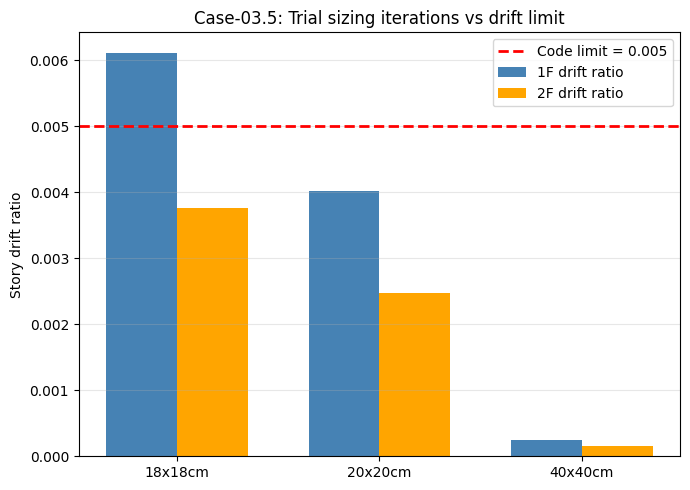

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

sizes_cm = [18, 20, 40]
drift1_list, drift2_list = [], []
for s in sizes_cm:
    _,_,d1,d2,_ = build_and_analyze(s/100, E, h1, h2, F1_frame, F2_frame)
    drift1_list.append(d1)
    drift2_list.append(d2)

fig, ax = plt.subplots(figsize=(7,5))
x = range(len(sizes_cm))
width = 0.35
ax.bar([i-width/2 for i in x], drift1_list, width, label='1F drift ratio', color='steelblue')
ax.bar([i+width/2 for i in x], drift2_list, width, label='2F drift ratio', color='orange')
ax.axhline(DRIFT_LIMIT, color='red', ls='--', lw=2, label=f'Code limit = {DRIFT_LIMIT}')
ax.set_xticks(list(x))
ax.set_xticklabels([f'{s}x{s}cm' for s in sizes_cm])
ax.set_ylabel('Story drift ratio')
ax.set_title('Case-03.5: Trial sizing iterations vs drift limit')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 總結表

In [8]:
print("="*55)
print("Case-03.5 試設斷面結果總結")
print("="*55)
print(f"{'F1_frame(單榀)':<24}{F1_frame:.4f} kN")
print(f"{'F2_frame(單榀)':<24}{F2_frame:.4f} kN")
print(f"{'混凝土 E':<24}{E:.4e} kN/m^2")
print(f"{'第0輪(18cm)':<24}{'FAIL'}")
print(f"{'第1輪(20cm)':<24}{'PASS (margin小)'}")
print(f"{'最終選定(40cm)':<24}{'PASS (有餘裕)'}")
print(f"{'最終Ic':<24}{Ic_final:.6f} m^4")
print()
print("Case-03.5 [PASS] -- 可以進到 Case-04(桃園案例, 已有前置法規計算)")

Case-03.5 試設斷面結果總結
F1_frame(單榀)            9.9375 kN
F2_frame(單榀)            15.9000 kN
混凝土 E                   2.4629e+07 kN/m^2
第0輪(18cm)               FAIL
第1輪(20cm)               PASS (margin小)
最終選定(40cm)              PASS (有餘裕)
最終Ic                    0.002133 m^4

Case-03.5 [PASS] -- 可以進到 Case-04(桃園案例, 已有前置法規計算)
